In [2]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from cdt.data import AcyclicGraphGenerator
from causallearn.search.ConstraintBased.PC import pc
from causallearn.graph.GeneralGraph import GeneralGraph
from pathlib import Path
import os

No GPU automatically detected. Setting SETTINGS.GPU to 0, and SETTINGS.NJOBS to cpu_count.


---
## Generating Synthetic Datasets

We define a custom class inheriting from AcyclicGraphGenerator in cdt. This allows us to provide an adjacency matrix from which cdt will generate a synthetic dataset according to, provided additional parameters such as the type of relationship in the structural causal model (linear, etc.).

As with the cdt documentation, we will use +1 in entry (i,j) to represent a directed edge from node i to node j.

We will experiment with two different types of DAGs, which we will refer to as "chain" and "loop" structured, which will be visualised below.

In [3]:
class CustomAcyclicGraphGenerator(AcyclicGraphGenerator):
    """
    A custom generator that uses a user-defined adjacency matrix
    to specify the causal graph structure. This class overrides the
    init_dag part of the base AcyclicGraphGenerator class in cdt.
    """
    
    def __init__(self, adjacency_matrix, causal_mechanism, **kwargs):
        
        # Get the number of nodes from the adjacency matrix
        nodes = adjacency_matrix.shape[0]
        super().__init__(causal_mechanism, nodes=nodes, **kwargs)
        # Store the provided adjacency matrix
        self.custom_adjacency_matrix = adjacency_matrix.copy()
    
    def init_dag(self, verbose=False):
        # Use the adjacency matrix we want (and not a random one as in the existing AcyclicGraphGenerator)
        self.adjacency_matrix = self.custom_adjacency_matrix.copy()
        
        # Create networkx graph and verify it's acyclic
        self.g = nx.DiGraph(self.adjacency_matrix)
        if list(nx.simple_cycles(self.g)):
            raise ValueError("Error: provided adjacency matrix contains cycles.")

In [4]:
def generate_chain_adj_matrix(n_features):
    """
    Generate an adjacency matrix for a chain-structured DAG.
    Each node i has a directed edge to node i+1, forming a simple chain.

    Args:
        n_features (int): Number of nodes in the chain.

    Returns:
        np.ndarray: Adjacency matrix of shape (n_features, n_features) representing the chain DAG.
    """

    adj_matrix = np.zeros((n_features, n_features), dtype=int)
    for i in range(n_features - 1):
        adj_matrix[i, i+1] = 1
        
    return adj_matrix

chain_100_adj_matrix = generate_chain_adj_matrix(100)

In [5]:
def add_direct_effects(input_adj_matrix,fraction):
    """
    Given a chain-structured adjacency matrix, add direct edges from early nodes
    to later nodes in the adjacency matrix.

    For the first (fraction//2) nodes, adds a direct edge from node i-1 to node (last-i).

    Args:
        input_adj_matrix (np.ndarray): The original adjacency matrix to modify.
        fraction (int): Determines the proportion of nodes to add direct edges for.

    Returns:
        np.ndarray: The modified adjacency matrix with additional direct edges.
    """
    
    for i in range(1, fraction//2 +1):
        input_adj_matrix[i-1, input_adj_matrix.shape[0]-i] = 1

    return input_adj_matrix

In [ ]:
# Add direct effects to the chain-structured adjacency matrix
loop_100_adj_matrix = add_direct_effects(generate_chain_adj_matrix(100),20)

---
## DAG Visualisation
LLM generated code

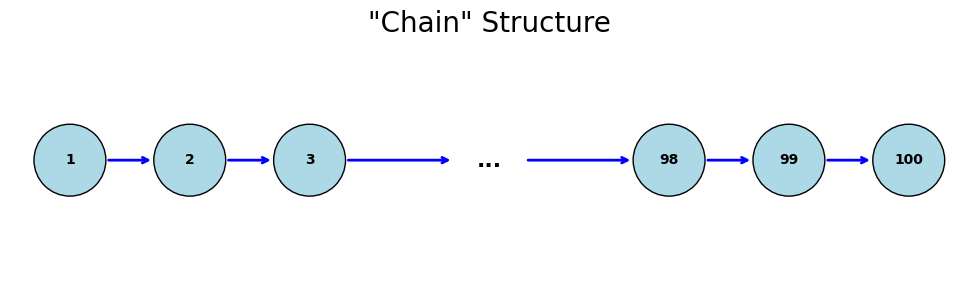

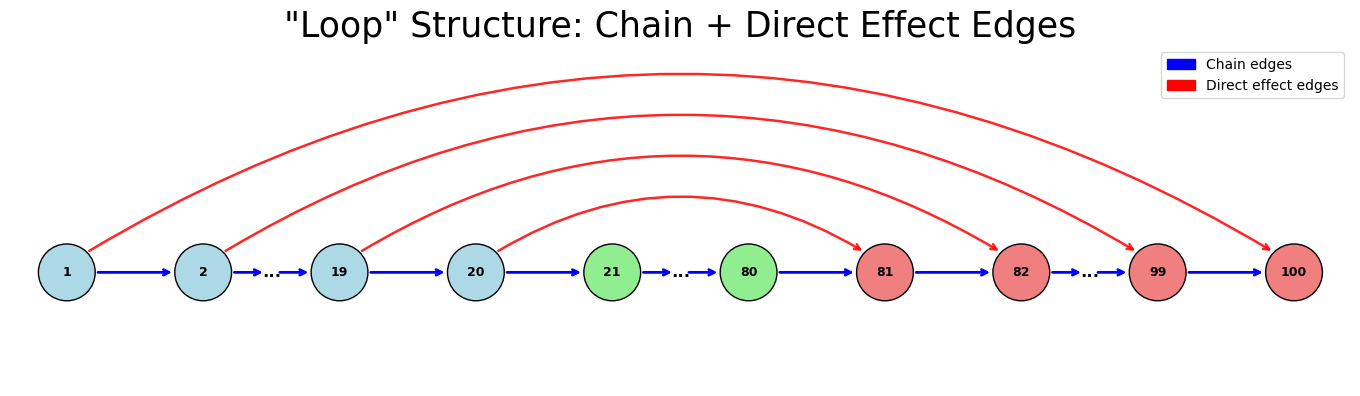

In [29]:
def visualize_chain_dag(adj_matrix, figsize=(15, 3)):
    """Visualize chain DAG in simplified linear format"""
    n_nodes = adj_matrix.shape[0]
    
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    
    # Define positions for key nodes
    key_positions = [0, 1, 2, n_nodes-3, n_nodes-2, n_nodes-1]  # 1,2,3,...,98,99,100
    x_positions = [0, 1, 2, 5, 6, 7]
    
    # Draw nodes
    for i, pos in enumerate(key_positions):
        node_label = str(pos + 1)  # 1-indexed for display
        circle = plt.Circle((x_positions[i], 0), 0.3, color='lightblue', ec='black')
        ax.add_patch(circle)
        ax.text(x_positions[i], 0, node_label, ha='center', va='center', fontsize=10, fontweight='bold')
    
    # Draw arrows between consecutive nodes
    arrow_pairs = [(0, 1), (1, 2), (3, 4), (4, 5)]  # Direct arrows: 1->2, 2->3, 98->99, 99->100
    for start_idx, end_idx in arrow_pairs:
        start_x, end_x = x_positions[start_idx], x_positions[end_idx]
        ax.annotate('', xy=(end_x - 0.3, 0), xytext=(start_x + 0.3, 0),
                   arrowprops=dict(arrowstyle='->', lw=2, color='blue'))
    
    # Draw the gap: 3 -> ... -> 98
    # Arrow from 3 to start of ellipsis
    ax.annotate('', xy=(3.2, 0), xytext=(2.3, 0),
               arrowprops=dict(arrowstyle='->', lw=2, color='blue'))
    
    # Ellipsis in the middle
    ax.text(3.5, 0, '...', ha='center', va='center', fontsize=16, fontweight='bold')
    
    # Arrow from end of ellipsis to 98
    ax.annotate('', xy=(4.7, 0), xytext=(3.8, 0),
               arrowprops=dict(arrowstyle='->', lw=2, color='blue'))
    
    ax.set_xlim(-0.5, 7.5)
    ax.set_ylim(-1, 1)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title('"Chain" Structure', fontsize=20)
    
    plt.tight_layout()
    return fig

def visualize_loop_dag(adj_matrix, figsize=(15, 4)):
    """Visualize loop DAG in clean linear format showing chain and direct effect edges"""
    _ = adj_matrix  # not used, but kept for API symmetry
    fig, ax = plt.subplots(1, 1, figsize=figsize)

    # Simple, clean node layout
    node_labels = ['1','2','19','20','21','80','81','82','99','100']
    spacing = 1.2  # uniform spacing between all nodes
    x_positions = [i * spacing for i in range(len(node_labels))]
    r = 0.25

    # Draw nodes
    for i, (label, x) in enumerate(zip(node_labels, x_positions)):
        if int(label) <= 20:
            color = 'lightblue'
        elif int(label) >= 81:
            color = 'lightcoral'
        else:
            color = 'lightgreen'
        ax.add_patch(plt.Circle((x, 0), r, color=color, ec='black'))
        ax.text(x, 0, label, ha='center', va='center', fontsize=9, fontweight='bold')

    # Blue arrows - all same length since spacing is uniform
    def blue_arrow(i, j):
        x1 = x_positions[i] + r
        x2 = x_positions[j] - r
        ax.annotate('', xy=(x2, 0), xytext=(x1, 0),
                    arrowprops=dict(arrowstyle='->', lw=2, color='blue'))

    # Draw explicit chain edges
    chain_pairs = [(0,1), (2,3), (3,4), (5,6), (6,7), (8,9)]
    for i, j in chain_pairs:
        blue_arrow(i, j)

    # Draw ellipsis sections
    def draw_ellipsis(i, j):
        x1, x2 = x_positions[i] + r, x_positions[j] - r
        # Left stub
        ax.annotate('', xy=(x1 + 0.3, 0), xytext=(x1, 0),
                    arrowprops=dict(arrowstyle='->', lw=2, color='blue'))
        # Right stub
        ax.annotate('', xy=(x2, 0), xytext=(x2 - 0.3, 0),
                    arrowprops=dict(arrowstyle='->', lw=2, color='blue'))
        # Dots
        ax.text((x_positions[i] + x_positions[j])/2, 0, '...', 
                ha='center', va='center', fontsize=12, fontweight='bold')

    draw_ellipsis(1, 2)  # 2 -> ... -> 19
    draw_ellipsis(4, 5)  # 21 -> ... -> 80
    draw_ellipsis(7, 8)  # 82 -> ... -> 99

    # Red direct effect arrows: 1→100, 2→99, 19→82, 20→81
    direct_edges = [(0,9), (1,8), (2,7), (3,6)]
    
    for i, j in direct_edges:
        x1, x2 = x_positions[i], x_positions[j]
        # Start and end at 45-degree angles on circles
        start_x = x1 + r * np.cos(np.pi/4)
        start_y = r * np.sin(np.pi/4)
        end_x = x2 + r * np.cos(3*np.pi/4)
        end_y = r * np.sin(3*np.pi/4)
        
        ax.annotate('', xy=(end_x, end_y), xytext=(start_x, start_y),
                    arrowprops=dict(arrowstyle='->', lw=1.8, color='red', alpha=0.85,
                                    connectionstyle="arc3,rad=-0.3"))

    # Formatting
    ax.legend(handles=[mpatches.Patch(color='blue', label='Chain edges'),
                       mpatches.Patch(color='red', label='Direct effect edges')],
              loc='upper right')
    
    ax.set_xlim(-0.5, max(x_positions) + 0.5)
    ax.set_ylim(-1, 2.0)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title('"Loop" Structure: Chain + Direct Effect Edges', fontsize=25)

    plt.tight_layout()
    return fig

# Visualize chain DAG
fig1 = visualize_chain_dag(chain_100_adj_matrix)
plt.show()

# Visualize loop DAG
fig2 = visualize_loop_dag(loop_100_adj_matrix)
plt.show()

The images above illustrate the 2 different ground-truth DAGs we will use to generate synthetic data according to.

---
## Data Generation

In [ ]:
# Define some dictionaries for easy access to causal mechanisms, adjacency matrices, and the 2 DAG types

causal_mechanisms = {
    '1': 'linear',
    '2': 'polynomial',
    '3': 'gaussian_process',
    '4': 'sigmoid',
    '5': 'nn'
}

adj_matrices = {
    1: chain_100_adj_matrix,
    2: loop_100_adj_matrix
}

dag_types = {
    1: 'chain',
    2: 'loop'
}

In [ ]:
# For each of the two DAG types, generate 100 synthetic datasets with 1000 points each, according to random linear SCMS
for dag_number in [1,2]:
    for i in range(100):
        generator = CustomAcyclicGraphGenerator(
            adjacency_matrix=adj_matrices[dag_number],
            causal_mechanism=causal_mechanisms['1'],
            npoints=1000
        )

        data, graph = generator.generate()

        folder = os.path.join(Path('./').resolve(), f'{dag_types[dag_number]}100data')
        file_name = f"dag{dag_number}dataset{i+1}.csv"
        file_path = os.path.join(folder, file_name)
        data.to_csv(file_path, index=False)